In [1]:
from rdkit import Chem
import numpy as np
from sklearn import metrics
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from rdkit.Chem import rdFingerprintGenerator
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.utils import shuffle
from sklearn.model_selection import ParameterGrid
import pickle

In [2]:
plt.rcParams.update(plt.rcParamsDefault)
%matplotlib inline
plt.style.use('seaborn-v0_8-paper')

In [3]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.notebook import tqdm

# Helper function (must be top-level for pickling in multiprocessing)
def evaluate_alpha(args):
    model_cls, train_X, train_y, val_X, val_y, alpha, num_runs = args
    grid_result = []
    for i in range(num_runs):
        X_train_shuffled, y_train_shuffled = shuffle(train_X, train_y)
        model = model_cls(**alpha)
        model.fit(X_train_shuffled, y_train_shuffled)
        y_pred = model.predict(val_X)
        val_error = mean_absolute_error(val_y, y_pred)
        grid_result.append(val_error)
    return (alpha, np.mean(grid_result), np.std(grid_result))

def grid_search_lr_parallel(model_cls, train_X, train_y, val_X, val_y, alpha_grid, num_runs=1, num_workers=64):
    args_list = [
        (model_cls, train_X, train_y, val_X, val_y, alpha, num_runs)
        for alpha in alpha_grid
    ]
    results = []
    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        # tqdm for progress bar
        futures = [executor.submit(evaluate_alpha, args) for args in args_list]
        for f in tqdm(as_completed(futures), total=len(futures)):
            results.append(f.result())
    return results


In [4]:
def plot_predictions(train_y, train_pred_y, val_y=None, val_pred_y=None, test_y=None, test_pred_y=None):
    
    fig, ax = plt.subplots(figsize=(3.2,3.2), dpi=600)
    ax.plot([1, 4.5], [1, 4.5], linestyle='--', c='k')
    ax.scatter(train_y, train_pred_y, alpha=0.4, s=15, label ="tadf train", c="royalblue")
    if val_pred_y is not None:
        ax.scatter(val_y, val_pred_y, alpha=0.4, s=15, label='tadf val')
    if test_pred_y is not None:
        ax.scatter(test_y, test_pred_y, alpha=0.4, s=15, label='tadf test', c="orangered")
    ax.set_xlim([1.4,4.1])
    ax.set_ylim([1.4,4.1])
    ax.legend(fontsize=9)
    ax.set_aspect('equal')
    ax.set_xlabel('True PL wavelengths / eV', size=9)
    ax.set_ylabel('Predicted PL wavelengths / eV', size=9)
    ax.text(x=2.75, y=1.5, 
            s="Train MAE:0.036\n"
            "Test  MAE:0.13\n"
            "Test  $R^2$: 0.79\n", fontsize=8, weight="semibold", family='monospace')
    ax.set_title('TADF PL Predictions',size=10)
    ax.tick_params(axis='both', which='major', labelsize=8)
    
    return fig, ax


### Compute FPs

In [5]:
def read_json_data(file):
    return pd.read_json(file)

def read_csv_data(file, sep=','):
    return pd.read_csv(file, sep=sep)

In [6]:
DATA_DIR = '../data_processing/tadf_pl/raw/'

In [7]:
def grid_search_lr(model_cls, train_X, train_y, val_X, val_y, alpha_grid, num_runs=1):
    results = []
    
    for alpha in alpha_grid:
        grid_result = []
        for i in range(num_runs):
            X_train_shuffled, y_train_shuffled = shuffle(train_X, train_y)
            
            model = model_cls(**alpha,)
            model.fit(X_train_shuffled, y_train_shuffled)
            
            y_pred = model.predict(val_X)
            val_error = mean_absolute_error(val_y, y_pred)
            grid_result.append(val_error)
            
        results.append((alpha, np.mean(grid_result), np.std(grid_result)))
    return results

In [8]:
block_mols = ["tadf_" + name for name in ['912', '619', '165', '878',  '35', '819', '889',  '38', '478']]

In [9]:
import os
def load_tadf_data():
    tadf_dataset = read_csv_data(DATA_DIR + 'TadfPL.csv', sep=',')

    with open(os.path.join(DATA_DIR, "test.csv"), "r") as f:
        test_names = [
            "tadf_" + line.split("|")[0] for line in f.read().split("\n")[1:-1]
        ]
    with open(os.path.join(DATA_DIR, "train.csv"), "r") as f:
        train_names = [
            "tadf_" + line.split("|")[0] for line in f.read().split("\n")[1:-1]
        ]
    
    with open(os.path.join(DATA_DIR, "val.csv"), "r") as f:
        val_names = [
            "tadf_" + line.split("|")[0] for line in f.read().split("\n")[1:-1]
        ]

    tadf_train = tadf_dataset[tadf_dataset['mol_id'].isin(train_names) & ~tadf_dataset['mol_id'].isin(block_mols)]
    tadf_test = tadf_dataset[tadf_dataset['mol_id'].isin(test_names) & ~tadf_dataset['mol_id'].isin(block_mols)]
    tadf_val = tadf_dataset[tadf_dataset['mol_id'].isin(val_names) & ~tadf_dataset['mol_id'].isin(block_mols)]

    return tadf_train, tadf_test, tadf_val

In [10]:
tadf_train, tadf_test, tadf_val = load_tadf_data()

In [14]:
tadf_train

,mol_id,pl,solvent,canonical_smiles
0,tadf_0,1.943326,Cc1ccccc1,c1ccc2c(c1)Oc1ccccc1N2c1ccc2c3c(cccc13)-c1nc3c...
1,tadf_1,1.940285,Cc1ccccc1,c1ccc2c(c1)Oc1ccccc1N2c1ccc2c(c1)c1ccccc1c1nc3...
2,tadf_2,2.666327,Cc1ccccc1,c1ccc(-c2nc(-c3ccccc3)nc(-c3ccccc3-n3c4ccccc4c...
4,tadf_4,2.817823,Cc1ccccc1,CC(C)(C)c1ccc2c(c1)c1cc(C(C)(C)C)ccc1n2CCCCCCC...
5,tadf_5,2.924156,Cc1ccccc1,CC(C)(C)c1ccc2c(c1)c1cc(C(C)(C)C)ccc1n2CCCCCCC...
...,...,...,...,...
644,tadf_1011,2.824241,CCCCCC,COc1cc(OC)c(-c2c(C(F)(F)F)cc(B(c3c(C(F)(F)F)cc...
645,tadf_1012,2.440634,Cc1ccccc1,Cc1ccc(-c2ccc3c(c2)c2cccc4c2n3-c2ccccc2O4)c2c1...
647,tadf_1014,2.460004,Cc1ccccc1,CC1(C)c2ccccc2N(c2ccc(S(=O)(=O)c3ccccc3-c3cccc...
648,tadf_1016,2.755204,Cc1ccccc1,Cc1nc(C)c(C#N)c(-c2ccc(-n3c4ccccc4c4ccccc43)cc...


In [15]:
train_mol = [Chem.MolFromSmiles(s) for s in tadf_train['canonical_smiles']]
train_y = tadf_train['pl']
val_mol = [Chem.MolFromSmiles(s) for s in tadf_val['canonical_smiles']]
val_y = tadf_val['pl']
test_mol = [Chem.MolFromSmiles(s) for s in tadf_test['canonical_smiles']]
test_y = tadf_test['pl']

In [16]:
# Just a constant value ~ the mean of the dataset.
print(f"Naive train rmse: {metrics.mean_absolute_error([2.5]*len(train_y), train_y)}")
print(f"Naive val   rmse: {metrics.mean_absolute_error([2.5]*len(val_y), val_y)}")

Naive train rmse: 0.3251245086140239
Naive val   rmse: 0.30075061372592143


In [17]:
rdkgen = rdFingerprintGenerator.GetRDKitFPGenerator(minPath=4, maxPath=10, fpSize=2**16, numBitsPerFeature=2, branchedPaths=True)

In [18]:
# set up train dataset

train_inputs = []

for m in train_mol[:]:
    ao = rdFingerprintGenerator.AdditionalOutput()
    ao.AllocateBitPaths()
    vect = rdkgen.GetFingerprint(m, additionalOutput=ao)
    train_inputs.append(
        {
            "features": vect,
            "bitpaths": ao.GetBitPaths()
        }
    )

train_inputs = pd.DataFrame(train_inputs)

In [19]:
# set up val dataset
val_inputs = []

for m in val_mol[:]:
    ao = rdFingerprintGenerator.AdditionalOutput()
    ao.AllocateBitPaths()
    vect = rdkgen.GetFingerprint(m, additionalOutput=ao)
    val_inputs.append(
        {
            "features": vect,
            "bitpaths": ao.GetBitPaths()
        }
    )

val_inputs = pd.DataFrame(val_inputs)

In [20]:
# set up test dataset
test_inputs = []
for m in test_mol[:]:
    ao = rdFingerprintGenerator.AdditionalOutput()
    ao.AllocateBitPaths()
    vect = rdkgen.GetFingerprint(m, additionalOutput=ao)
    test_inputs.append(
        {
            "features": vect,
            "bitpaths": ao.GetBitPaths()
        }
    )
test_inputs = pd.DataFrame(test_inputs)

In [21]:
train_X = train_inputs["features"].tolist()
val_X = val_inputs["features"].tolist()
test_X = test_inputs["features"].tolist()

In [22]:
train_X = [X.ToList() for X in train_X]
val_X = [X.ToList() for X in val_X]
test_X = [X.ToList() for X in test_X]

### Save FPs

In [23]:
with open('./rdkit_4_10_65536_branched/train.pkl','wb+') as outf:
    pickle.dump({'fps': train_X,
                  'pl': train_y}, outf)

In [24]:
with open('./rdkit_4_10_65536_branched/val.pkl','wb+') as outf:
    pickle.dump({'fps': val_X,
                  'pl': val_y}, outf)

In [25]:
with open('./rdkit_4_10_65536_branched/test.pkl','wb+') as outf:
    pickle.dump({'fps': test_X,
                  'pl': test_y}, outf)

### Load FPs

In [25]:
with open('./rdkit_4_10_65536_branched/train.pkl','rb') as f:
    train_data = pickle.load(f)
X_train = np.array(train_data['fps'], dtype=int)
y_train = np.array(train_data['pl'], dtype=float)

In [26]:
with open('./rdkit_4_10_65536_branched/val.pkl','rb') as f:
    val_data = pickle.load(f)
X_val = np.array(val_data['fps'], dtype=int)
y_val = np.array(val_data['pl'], dtype=float)

In [27]:
with open('./rdkit_4_10_65536_branched/test.pkl','rb') as f:
    test_data = pickle.load(f)
X_test = np.array(test_data['fps'], dtype=int)
y_test = np.array(test_data['pl'], dtype=float)

In [28]:
X_full_train = np.concatenate([X_train, X_val])
y_full_train = np.concatenate([y_train, y_val])

Train MAE: 0.03594164447355283
Test MAE: 0.12919192144744307
Test R2: 0.7886307154957468


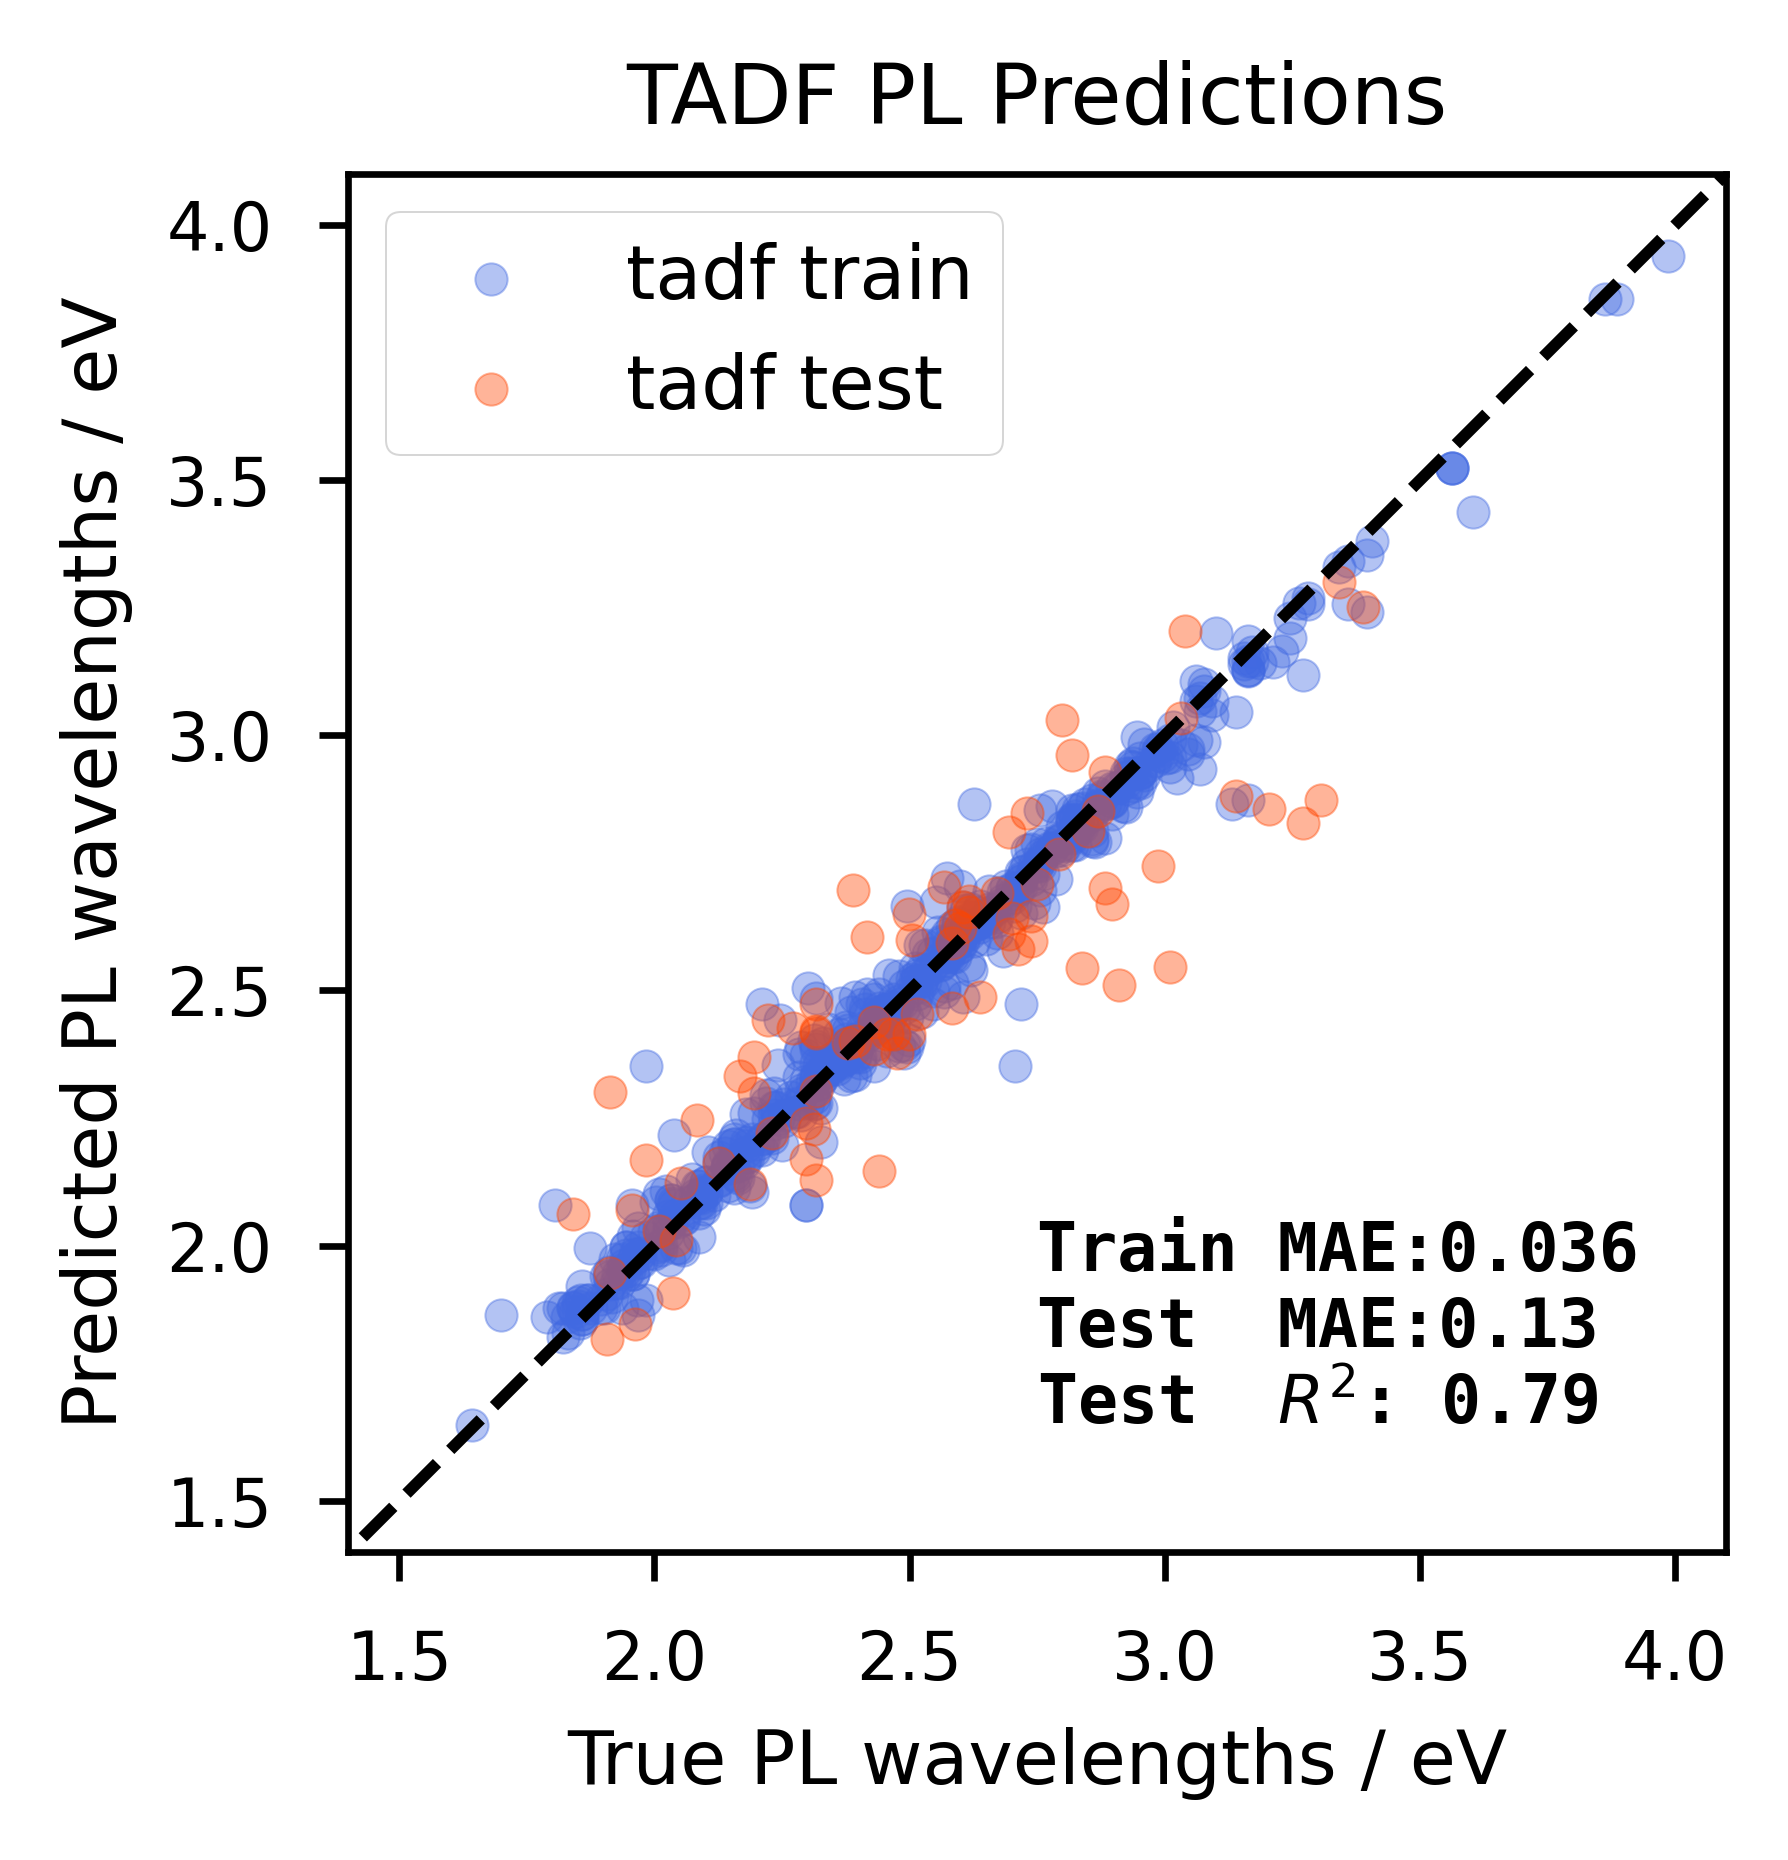

In [29]:
model_0 = linear_model.Ridge(alpha=220).fit(X_full_train, y_full_train)
pred_train_y = model_0.predict(X_full_train)

train_mae = metrics.mean_absolute_error(y_full_train, pred_train_y)
print(f"Train MAE: {train_mae}")

pred_test_y = model_0.predict(X_test)
pairs_test = np.array(list(zip(y_test, pred_test_y)))
test_mae = metrics.mean_absolute_error(pairs_test[:, 0], pairs_test[:, 1])
print(f"Test MAE: {test_mae}")

test_r2 = metrics.r2_score(y_test, pred_test_y)
print(f"Test R2: {test_r2}")

fig, ax = plot_predictions(y_full_train, pred_train_y, test_y=y_test, test_pred_y=pred_test_y)
plt.tight_layout()

In [30]:
fig.savefig('../figures/plain_ridge_best_scatter.png', dpi=600)

In [38]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

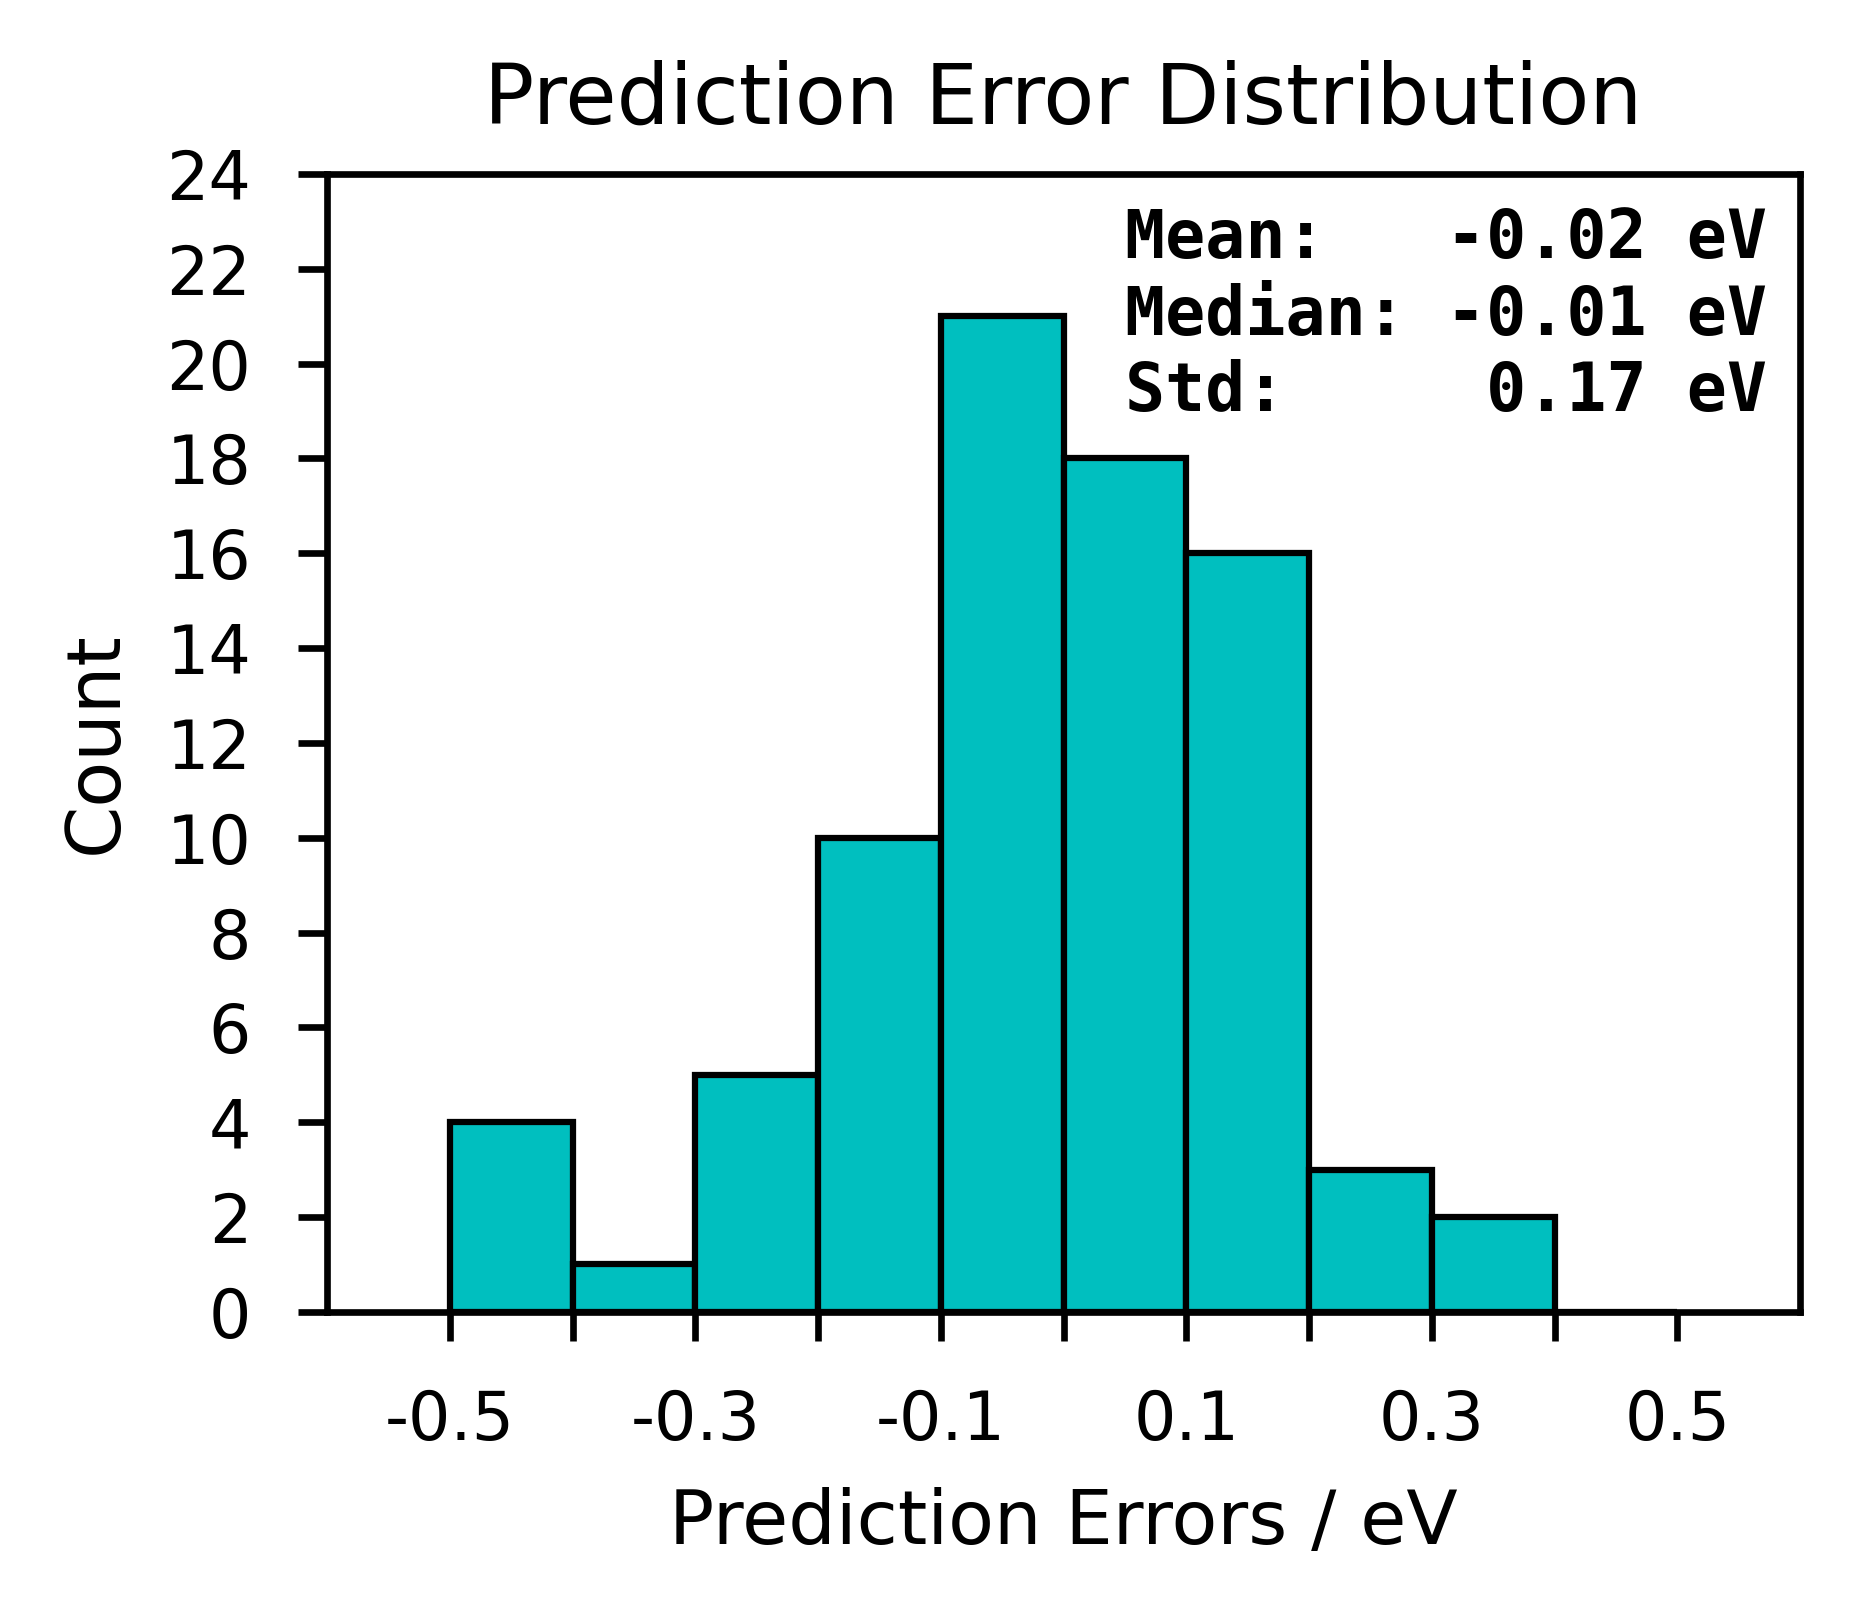

In [18]:
plt.rcParams.update(plt.rcParamsDefault)
%matplotlib inline
plt.style.use('seaborn-v0_8-paper')

errors = pred_test_y - y_test
fig, ax = plt.subplots(figsize=(3.2,2.8), dpi=600)
error_mean = np.mean(errors)
error_median = np.median(errors)
error_std = np.std(errors)

bins=np.linspace(-0.5, 0.5, 11)
hist = ax.hist(errors, bins=bins, edgecolor='k', color='c', linewidth=0.75)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.set_xticks(ticks=bins, labels=[-0.5, None, -0.3, None, -0.1, None, 0.1, None, 0.3, None, 0.5])
ax.set_yticks(np.arange(0, 26, 2))
ax.tick_params(axis='both', which='major', labelsize=8)
ax.set_xlabel("Prediction Errors / eV", size=9)
ax.set_ylabel("Count", size=9)
ax.set_xlim(-0.6,0.6)
ax.set_ylim(0, 24)
ax.set_title("Prediction Error Distribution", size=10)
ax.grid(visible=False)
ax.text(
    x=0.05,
    y=19,
    s=f"Mean:   {error_mean:.2f} eV\n"
      f"Median: {error_median:.2f} eV\n"
      f"Std:     {error_std:.2f} eV",
    size=8,
    family="monospace",
    weight="semibold"
)
plt.tight_layout()
plt.show()
fig.savefig('../figures/plain_ridge_error_dist.png', dpi=600)

In [22]:
def bootstrap_mae(y_true, y_pred, n_bootstraps=100000, random_seed=42):
    rng = np.random.default_rng(random_seed)
    n_samples = len(y_true)
    mae_scores = []

    for _ in range(n_bootstraps):
        # Sample indices with replacement
        indices = rng.integers(0, n_samples, n_samples)
        y_true_sample = y_true[indices]
        y_pred_sample = y_pred[indices]
        
        # Compute MAE on the bootstrap sample
        score = mean_absolute_error(y_true_sample, y_pred_sample)
        mae_scores.append(score)

    mae_scores = np.array(mae_scores)
    
    # Compute statistics
    mae_mean = np.mean(mae_scores)
    mae_std = np.std(mae_scores)
    ci_lower = np.percentile(mae_scores, 5)
    ci_upper = np.percentile(mae_scores, 95)
    
    return {
        "mae_mean": mae_mean,
        "mae_std": mae_std,
        "90%_CI": (ci_lower, ci_upper),
        "all_scores": mae_scores  # Optional, if you want to visualize later
    }

In [23]:
scores = bootstrap_mae(y_test, pred_test_y,)
for k, v in scores.items():
    print(k, v)

mae_mean 0.12920747731795096
mae_std 0.01227858509163814
90%_CI (np.float64(0.10949498998572135), np.float64(0.1499642438023817))
all_scores [0.11786879 0.11778123 0.10878746 ... 0.12761437 0.13090871 0.1284851 ]


In [19]:
from sklearn.feature_selection import RFE

In [20]:
rgs = linear_model.Ridge(alpha=10)

In [47]:
rfe = RFE(
    estimator=rgs,
    n_features_to_select=8192,
    step=0.01,
)

In [48]:
rfe.fit(X_train, y_train)

RFE(estimator=Ridge(alpha=10), n_features_to_select=8192, step=0.01)

In [49]:
X_train_selected = rfe.transform(X_train)
X_val_selected = rfe.transform(X_val)

In [52]:
# Hyperparameter grid
alpha_grid = ParameterGrid({'alpha': [10*i+300 for i in range(1, 11)]})

# Display results
results = grid_search_lr(linear_model.Ridge, X_train_selected, y_train, X_val_selected, y_val, alpha_grid)
for alpha, val_err, _ in results:
    print(f"Alpha: {alpha}, Avg MAE: {val_err:.4f}")

# Get best alpha
best_alpha = min(results, key=lambda x: x[1])
print(f"\nBest alpha: {best_alpha}")

Alpha: {'alpha': 310}, Avg MAE: 0.1774
Alpha: {'alpha': 320}, Avg MAE: 0.1774
Alpha: {'alpha': 330}, Avg MAE: 0.1774
Alpha: {'alpha': 340}, Avg MAE: 0.1774
Alpha: {'alpha': 350}, Avg MAE: 0.1774
Alpha: {'alpha': 360}, Avg MAE: 0.1774
Alpha: {'alpha': 370}, Avg MAE: 0.1774
Alpha: {'alpha': 380}, Avg MAE: 0.1774
Alpha: {'alpha': 390}, Avg MAE: 0.1775
Alpha: {'alpha': 400}, Avg MAE: 0.1775

Best alpha: ({'alpha': 380}, np.float64(0.1774304905187253), np.float64(0.0))


In [9]:
X_full_train_selected = np.concatenate((X_train_selected, X_val_selected))
y_full_train = np.concatenate((y_train, y_val))

NameError: name 'X_train_selected' is not defined

In [ ]:
X_test_selected = rfe.transform(X_test)

Train MAE: 0.056609077571645516
Test MAE: 0.1283560635004802
Test R2: 0.8007389727886309


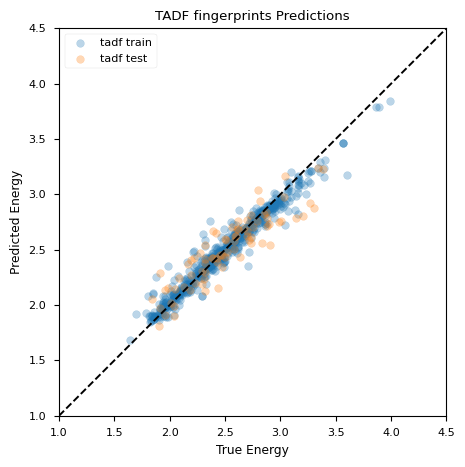

In [55]:
model = linear_model.Ridge(alpha=310)
model.fit(X_full_train_selected, y_full_train)

pred_train_y = model.predict(X_full_train_selected)

train_mae = metrics.mean_absolute_error(y_full_train, pred_train_y)
print(f"Train MAE: {train_mae}")

pred_test_y = model.predict(X_test_selected)
pairs_test = np.array(list(zip(y_test, pred_test_y)))
test_mae = metrics.mean_absolute_error(pairs_test[:, 0], pairs_test[:, 1])
print(f"Test MAE: {test_mae}")

test_r2 = metrics.r2_score(y_test, pred_test_y)
print(f"Test R2: {test_r2}")

plot_predictions(y_full_train, pred_train_y, test_y=y_test, test_pred_y=pred_test_y)

In [11]:
params = {
    "n_estimators": [300,],
    "max_depth": [7, 8],
    "min_samples_split": [3,],
    "min_samples_leaf": [1, 2, 4],
    "learning_rate": [0.01, 0.1],
    "loss": ["squared_error"],
}
alpha_grid = ParameterGrid(params)

In [9]:
from sklearn import ensemble

In [ ]:
reg = ensemble.GradientBoostingRegressor(**{'learning_rate': 0.1, 
                                            'loss': 'squared_error', 
                                            'max_depth': 7, 
                                            'min_samples_leaf': 2, 
                                            'min_samples_split': 3, 
                                            'n_estimators': 300})
reg.fit(X_full_train, y_full_train)

In [12]:
results = grid_search_lr_parallel(ensemble.GradientBoostingRegressor, X_train, y_train, X_val, y_val, alpha_grid, num_workers=12)
for alpha, val_err, _ in results:
    print(f"Alpha: {alpha}, Avg MAE: {val_err:.4f}")

  0%|          | 0/12 [00:00<?, ?it/s]

Alpha: {'learning_rate': 0.01, 'loss': 'squared_error', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 300}, Avg MAE: 0.1894
Alpha: {'learning_rate': 0.01, 'loss': 'squared_error', 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 300}, Avg MAE: 0.1924
Alpha: {'learning_rate': 0.01, 'loss': 'squared_error', 'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 300}, Avg MAE: 0.1938
Alpha: {'learning_rate': 0.1, 'loss': 'squared_error', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 300}, Avg MAE: 0.1883
Alpha: {'learning_rate': 0.1, 'loss': 'squared_error', 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 300}, Avg MAE: 0.1952
Alpha: {'learning_rate': 0.01, 'loss': 'squared_error', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 300}, Avg MAE: 0.1886
Alpha: {'learning_rate': 0.01, 'loss': 'squared_error', 'max

In [ ]:
pred_train_y = reg.predict(X_full_train)
train_mae = metrics.mean_absolute_error(y_full_train, pred_train_y)
print(f"Train MAE: {train_mae}")

pred_test_y = reg.predict(X_test)
test_mae = metrics.mean_absolute_error(y_test, pred_test_y)
print(f"test MAE: {test_mae}")